<div style="background: linear-gradient(120deg, #1a3a5c 0%, #2d6a9f 60%, #4a9eda 100%); padding: 28px 36px; border-radius: 14px; display: flex; align-items: center; gap: 28px; box-shadow: 0 4px 18px rgba(0,0,0,0.18);">
    <img src='Figures/iteso.jpg' style="height: 110px; border-radius: 8px; background: white; padding: 6px; flex-shrink: 0; box-shadow: 0 2px 8px rgba(0,0,0,0.2);"/>
    <div style="border-left: 2px solid rgba(255,255,255,0.4); padding-left: 28px;">
        <h1 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Módulo 2: Distribución de datos</h1>
        <h3 style="margin: 0 0 8px 0; color: white; font-size: 1.15em; line-height: 1.3;">Ingeniería de Características</h3>
        <h3 style="margin: 0; color: rgba(255,255,255,0.8); font-weight: normal; font-size: 1.05em;">Maestría en Ciencia de Datos</h3>
    </div>
</div>

> una distribución no se entiende con un único número. Combina gráficos, medidas de posición, dispersión y forma para decidir cómo tratar una variable.


In [1]:
from scipy import stats
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.float_format', '{:,.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
wine = load_wine(as_frame=True)
df = wine.data.copy()
df['target'] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.230,1.710,2.430,15.600,127.000,2.800,3.060,0.280,2.290,5.640,1.040,3.920,"1,065.000",0
1,13.200,1.780,2.140,11.200,100.000,2.650,2.760,0.260,1.280,4.380,1.050,3.400,"1,050.000",0
2,13.160,2.360,2.670,18.600,101.000,2.800,3.240,0.300,2.810,5.680,1.030,3.170,"1,185.000",0
3,14.370,1.950,2.500,16.800,113.000,3.850,3.490,0.240,2.180,7.800,0.860,3.450,"1,480.000",0
4,13.240,2.590,2.870,21.000,118.000,2.800,2.690,0.390,1.820,4.320,1.040,2.930,735.000,0


## ¿Qué significa la distribución de una variable?

La **distribución** describe cómo se reparten los valores: dónde se concentran, qué tan dispersos están, si existen colas, grupos o valores extremos. No es lo mismo que una distribución normal; la normal es solo un modelo posible.

En este cuaderno usaremos la variable `alcohol` del dataset Wine. El objetivo es practicar un flujo de diagnóstico:

1. Revisar escala y valores faltantes.
2. Observar histograma y diagrama de cajas.
3. Resumir con media, mediana y cuantiles.
4. Medir dispersión y forma.
5. Comparar la evidencia antes de decidir una transformación.

Referencias: [scikit-learn: dataset Wine](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) · [Matplotlib: histogramas](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html) · [SciPy: estadística](https://docs.scipy.org/doc/scipy/reference/stats.html)

In [3]:
#'total phenols'
#df.loc[:,'total phenols']

In [4]:
feature = df['alcohol']
print(f'Observaciones: {feature.size}')
print(f'Faltantes: {feature.isna().sum()}')
print(f'Rango: {feature.min():.2f} a {feature.max():.2f}')
feature.describe()

Observaciones: 178
Faltantes: 0
Rango: 11.03 a 14.83


count   178.000
mean     13.001
std       0.812
min      11.030
25%      12.362
50%      13.050
75%      13.678
max      14.830
Name: alcohol, dtype: float64

### Antes de graficar: conocer la variable

La misma técnica no sirve para todos los tipos de datos. Un histograma es apropiado para una variable cuantitativa; para una categoría conviene usar frecuencias o proporciones.

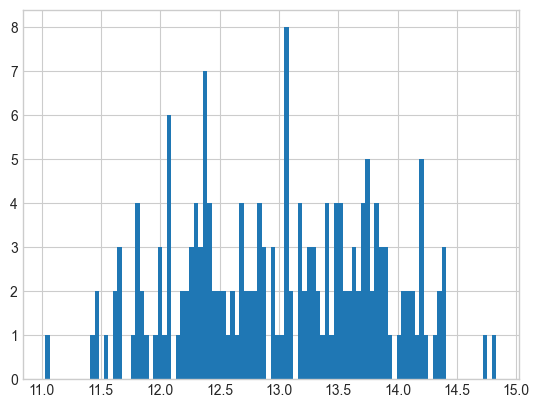

In [5]:
x=df.alcohol # objeto de tipo series
h=x.hist(bins=100)

In [6]:
#Mostrar todas las distribuciones


### Histograma, caja y gráfico Q-Q

Cada gráfico responde una pregunta distinta:

- **Histograma:** ¿dónde se concentran los valores y hay colas o grupos?
- **Caja:** ¿cuál es el centro, el 50% central y qué observaciones podrían ser extremas?
- **Q-Q:** ¿qué tan cerca están los cuantiles observados de los cuantiles de una normal?

Un Q-Q plot alineado no demuestra normalidad; solo indica compatibilidad visual con ese modelo.

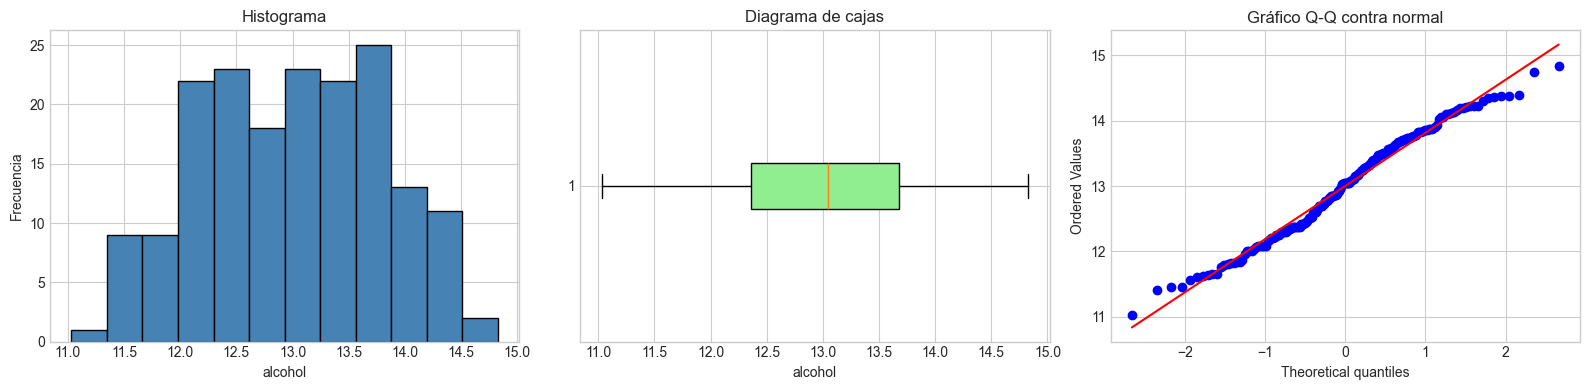

In [7]:
#Plot del histograma, diagrama de caja y un grafico q-q
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(x, bins=12, color='steelblue', edgecolor='black')
axes[0].set_title('Histograma')
axes[0].set_xlabel('alcohol')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(x, vert=False, patch_artist=True, boxprops={'facecolor': 'lightgreen'})
axes[1].set_title('Diagrama de cajas')
axes[1].set_xlabel('alcohol')

stats.probplot(x, dist='norm', plot=axes[2])
axes[2].set_title('Gráfico Q-Q contra normal')

plt.tight_layout()
plt.show()

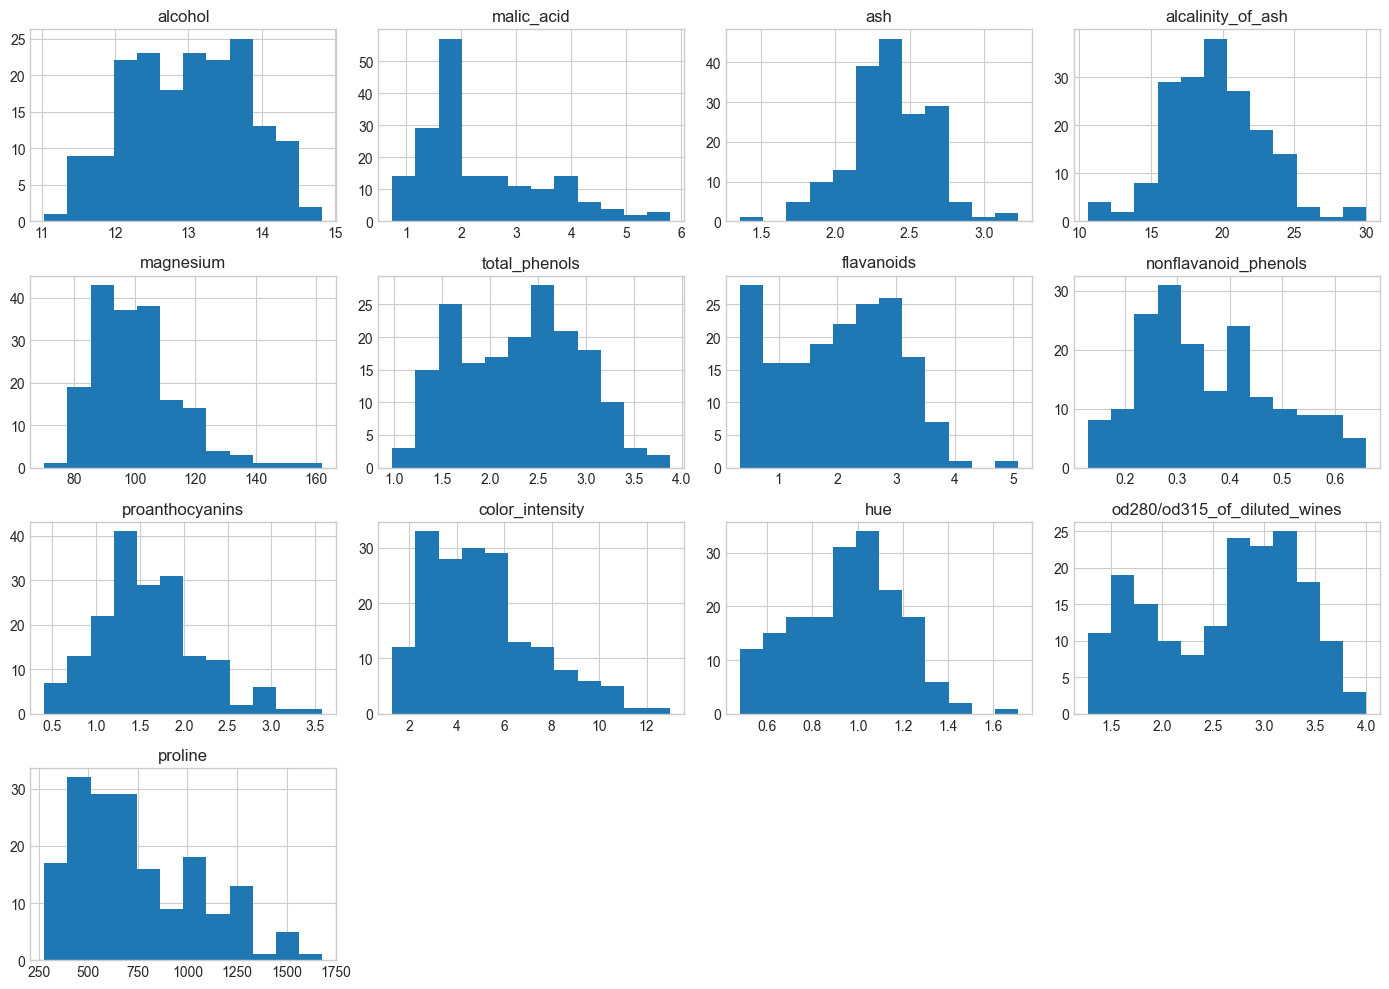

In [8]:
df.drop(columns='target').hist(figsize=(14, 10), bins=12)
plt.tight_layout()
plt.show()

# Medidas de posición o de tendencia central

### Media aritmética

La **media** es el promedio aritmético de un conjunto de datos.

$$ \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i $$

Donde $x_i$ son los valores y $n$ es el número total de datos.

In [9]:
# Ejemplo de cálculo de la media en Python
datos = [10, 12, 15, 18, 20] # conjunto de datos
media = np.mean(datos)       # cálculo de la media con python
print('Media:', media) 

Media: 15.0


In [10]:
# Considerando la característica "alcohol" del dataframe df
x.mean()

np.float64(13.00061797752809)

In [11]:
#Esto es equivalente a utilizar el método de la librería de numpy
np.mean(x)

np.float64(13.00061797752809)

In [12]:
# Obtención de la media de todas las características en el dataset
s_mean = df.mean()
s_mean

alcohol                         13.001
malic_acid                       2.336
ash                              2.367
alcalinity_of_ash               19.495
magnesium                       99.742
total_phenols                    2.295
flavanoids                       2.029
nonflavanoid_phenols             0.362
proanthocyanins                  1.591
color_intensity                  5.058
hue                              0.957
od280/od315_of_diluted_wines     2.612
proline                        746.893
target                           0.938
dtype: float64

In [13]:
#Media de la carcaterística flavanoids
s_mean['flavanoids'] 

np.float64(2.0292696629213487)

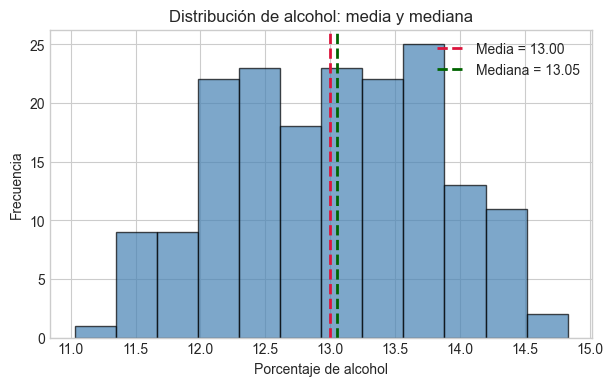

In [14]:
plt.figure(figsize=(7, 4))
plt.hist(x, bins=12, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(x.mean(), color='crimson', linestyle='--', linewidth=2, label=f'Media = {x.mean():.2f}')
plt.axvline(x.median(), color='darkgreen', linestyle='--', linewidth=2, label=f'Mediana = {x.median():.2f}')
plt.title('Distribución de alcohol: media y mediana')
plt.xlabel('Porcentaje de alcohol')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

### Media Recortada

La **media recortada** es una medida de tendencia central que se calcula eliminando un porcentaje igual de los valores más bajos y más altos de un conjunto de datos antes de calcular la media. Esto reduce el efecto de los valores atípicos (outliers) en el promedio.

La media recortada del $p\%$ se calcula eliminando el $p\%$ de los datos más pequeños y el $p\%$ de los datos más grandes, y luego calculando la media de los datos restantes.

Sea el conjunto de datos definido como sigue: $X=\{x_1 \leq x_2 \leq ... \leq x_n\}$

Si consideramos un $p$ porcentaje que se desea recortar y a $n$ como el número de elementos totales del conjunto de datos.

Entonces:

$$r = floor(n*p/100)$$ 

$$X_{t} = \{x_{1+r},..,x_{n-r}\}$$

Fórmula:

$$ \bar{x}_{recortada} = \frac{1}{n-2r} \sum_{i=r+1}^{n-r} x_{i} $$

donde $r$ es el número de valores eliminados en cada extremo y $x_{i}$ son los datos ordenados.

In [15]:
def media_recortada(datos, porcentaje_recorte):
    media_recortada = None
    n = len(datos)
    r = int(n * porcentaje_recorte)
    datos_ordenados = sorted(datos)
    datos_recortados = datos_ordenados[r:n-r] if n - 2*r > 0 else []
    if datos_recortados:
        media_recortada = sum(datos_recortados) / len(datos_recortados)
        print(f'Media recortada ({porcentaje_recorte*100}%): {media_recortada}', )
    else:
        print('No hay suficientes datos para calcular la media recortada con este porcentaje.')
    return media_recortada

In [16]:
x

0     14.230
1     13.200
2     13.160
3     14.370
4     13.240
       ...  
173   13.710
174   13.400
175   13.270
176   13.170
177   14.130
Name: alcohol, Length: 178, dtype: float64

In [17]:
media_recortada(x, 0.1)

Media recortada (10.0%): 13.006388888888887


13.006388888888887

In [18]:
stats.tmean?

Signature:
stats.tmean(
    a,
    limits=None,
    inclusive=(True, True),
    axis=None,
    *,
    nan_policy='propagate',
    keepdims=False,
)
Docstring:
Compute the trimmed mean.

This function finds the arithmetic mean of given values, ignoring values
outside the given `limits`.

Parameters
----------
a : array_like
    Array of values.
limits : None or (lower limit, upper limit), optional
    Values in the input array less than the lower limit or greater than the
    upper limit will be ignored.  When limits is None (default), then all
    values are used.  Either of the limit values in the tuple can also be
    None representing a half-open interval.
inclusive : (bool, bool), optional
    A tuple consisting of the (lower flag, upper flag).  These flags
    determine whether values exactly equal to the lower or upper limits
    are included.  The default value is (True, True).
axis : int or None, default: None
    If an int, the axis of the input along which to compute the stat

In [19]:
stats.tmean(x,(12,14)) # Conociendo el limite inferior y superior

np.float64(12.983576642335766)

In [20]:
stats.trim_mean?

Signature: stats.trim_mean(a, proportiontocut, axis=0)
Docstring:
Return mean of array after trimming a specified fraction of extreme values

Removes the specified proportion of elements from *each* end of the
sorted array, then computes the mean of the remaining elements.

Parameters
----------
a : array_like
    Input array.
proportiontocut : float
    Fraction of the most positive and most negative elements to remove.
    When the specified proportion does not result in an integer number of
    elements, the number of elements to trim is rounded down.
axis : int or None, default: 0
    Axis along which the trimmed means are computed.
    If None, compute over the raveled array.

Returns
-------
trim_mean : ndarray
    Mean of trimmed array.

See Also
--------
trimboth : Remove a proportion of elements from each end of an array.
tmean : Compute the mean after trimming values outside specified limits.

Notes
-----
For 1-D array `a`, `trim_mean` is approximately equivalent to the follo

In [21]:
stats.trim_mean(x,0.1)

np.float64(13.006388888888889)

In [22]:
#Ejenplo para una arreglo
x2 = np.array([1.3,1.5,2.0,4.7,8.9,10,11.5])
x2

array([ 1.3,  1.5,  2. ,  4.7,  8.9, 10. , 11.5])

In [23]:
# p 5% de los datos
stats.trim_mean(x2,0.05), x2.mean()

(np.float64(5.7), np.float64(5.7))

In [24]:
# p 15%
stats.trim_mean(x2,0.15), x2.mean()

(np.float64(5.42), np.float64(5.7))

La media recortada puede ayudarnos a:
- Reducir el efecto de los valores atípicos (outliers) en el cálculo de la media.
- Proporcionar una medida de tendencia central más robusta en distribuciones sesgadas o con extremos.

Sin embargo:
- Se puede perder información al eliminar datos, lo que puede ser problemático si el conjunto de datos es pequeño.
- El porcentaje de recorte debe elegirse cuidadosamente; un valor inadecuado puede distorsionar los resultados.


### Media ponderada

Toma en cuenta la importancia o peso de cada valor en el conjunto de datos. Es útil cuando algunos datos tienen mayor relevancia que otros.


$$ \bar{x}_p = \frac{\sum_{i=1}^{n} w_i x_i}{\sum_{i=1}^{n} w_i} $$

Donde:
- $x_i$ son los valores de los datos.
- $w_i$ son los pesos asignados a cada valor.
- $n$ es el número total de datos.

Considere las siguientes calificaciones y pesos de la materia:

- Examen 1: 80 (peso 20%)
- Examen 2: 90 (peso 30%)
- Proyecto: 95 (peso 50%)

La media ponderada sería:

$$ \bar{x}_p = \frac{80 \times 0.2 + 90 \times 0.3 + 95 \times 0.5}{0.2 + 0.3 + 0.5} = 91.5 $$

In [25]:
np.average?

Signature:      
np.average(
    a,
    axis=None,
    weights=None,
    returned=False,
    *,
    keepdims=<no value>,
)
Call signature:  np.average(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function average at 0x0000018D022123B0>
File:            c:\users\uie70742\.conda\envs\ic_curso_2026\lib\site-packages\numpy\lib\_function_base_impl.py
Docstring:      
Compute the weighted average along the specified axis.

Parameters
----------
a : array_like
    Array containing data to be averaged. If `a` is not an array, a
    conversion is attempted.
axis : None or int or tuple of ints, optional
    Axis or axes along which to average `a`.  The default,
    `axis=None`, will average over all of the elements of the input array.
    If axis is negative it counts from the last to the first axis.
    If axis is a tuple of ints, averaging is performed on all of the axes
    specified in the tuple instead of a single axis or all the axes as
    before.
weights :

In [26]:
x

0     14.230
1     13.200
2     13.160
3     14.370
4     13.240
       ...  
173   13.710
174   13.400
175   13.270
176   13.170
177   14.130
Name: alcohol, Length: 178, dtype: float64

In [27]:
np.average(x)

np.float64(13.00061797752809)

In [28]:
x.shape

(178,)

In [29]:
w=np.ones(x.shape) # [1,1,1,...,1]
w[0]=2              # A la primera observación le estamos dando el doble de importancia

In [30]:
x[0]

np.float64(14.23)

In [31]:
np.average(x,weights=w) # Media ponderada

np.float64(13.007486033519553)

La media ponderada:
- Permite dar mayor importancia a ciertos valores según su relevancia.
- Es útil en situaciones donde los datos no tienen la misma representatividad.
- Refleja mejor la realidad en contextos como calificaciones, encuestas o promedios ponderados.

Sin embargo: 
- Requiere conocer los pesos adecuados para cada valor.
- Si los pesos no están bien definidos, el resultado puede ser engañoso.
- Puede ser más compleja de calcular y entender que la media simple.

### Media geométrica

Se utiliza principalmente para datos positivos y multiplicativos, como tasas de crecimiento, rendimientos financieros o proporciones.

$$ \bar{x}_g = \sqrt[n]{x_1 \cdot x_2 \cdot \ldots \cdot x_n} $$

Donde:
- $x_1, x_2, \ldots, x_n$ son los valores del conjunto de datos.
- $n$ es el número total de valores.

Es especialmente útil cuando los datos representan factores de cambio relativos (por ejemplo, tasas de crecimiento anual). A diferencia de la media aritmética, la media geométrica minimiza el impacto de valores extremos altos y es más apropiada para promediar razones o porcentajes.

Supongamos que una inversión crece los siguientes años a tasas del 10%, 20% y 30%. Para calcular la tasa promedio de crecimiento:

- Convertimos los porcentajes a factores: 1.10, 1.20, 1.30
- Aplicamos la fórmula:

$$ \bar{x}_g = \sqrt[3]{1.10 \times 1.20 \times 1.30} \approx 1.196 $$

La tasa promedio de crecimiento es aproximadamente 19.6%.

In [32]:
tasas = [1.10, 1.20, 1.30]
media_geom = stats.gmean(tasas)
print('Media geométrica de las tasas de crecimiento:', media_geom, 'ó', (media_geom-1)*100, '%')

Media geométrica de las tasas de crecimiento: 1.197215767258376 ó 19.721576725837608 %


In [33]:
stats.gmean?

Signature:
stats.gmean(
    a,
    axis=0,
    dtype=None,
    weights=None,
    *,
    nan_policy='propagate',
    keepdims=False,
)
Docstring:
Compute the weighted geometric mean along the specified axis.

The weighted geometric mean of the array :math:`a_i` associated to weights
:math:`w_i` is:

.. math::

    \exp \left( \frac{ \sum_{i=1}^n w_i \ln a_i }{ \sum_{i=1}^n w_i }
               \right) \, ,

and, with equal weights, it gives:

.. math::

    \sqrt[n]{ \prod_{i=1}^n a_i } \, .

Parameters
----------
a : array_like
    Input array or object that can be converted to an array.
axis : int or None, default: 0
    If an int, the axis of the input along which to compute the statistic.
    The statistic of each axis-slice (e.g. row) of the input will appear in a
    corresponding element of the output.
    If ``None``, the input will be raveled before computing the statistic.
dtype : dtype, optional
    Type to which the input arrays are cast before the calculation is
    perform

In [34]:
#Media geométrica
stats.gmean(x)

np.float64(12.975278352602606)

La media geométrica:
- Es adecuada para promediar tasas de crecimiento, razones y porcentajes.
- Reduce el impacto de valores extremos altos.
- Refleja mejor el comportamiento multiplicativo de los datos.

Sin embargo:
- Solo se puede aplicar a datos positivos.
- No es adecuada para datos con valores negativos o nulos.

### Media armónica  

Se utiliza principalmente cuando los datos son tasas o razones, como velocidades o precios unitarios.

$$ \bar{x}_a = \frac{n}{\sum_{i=1}^{n} \frac{1}{x_i}} $$

Donde:
- $x_i$ son los valores del conjunto de datos.
- $n$ es el número total de valores.

Es especialmente útil cuando se desea promediar magnitudes que se expresan como "por unidad" (por ejemplo, velocidad promedio en trayectos de igual distancia, o costo promedio por unidad).

A diferencia de la media aritmética y la geométrica, la media armónica da más peso a los valores pequeños.


Supongamos que un automóvil recorre una distancia a $60 km/h$ y regresa a $40 km/h$. ¿Cuál es la velocidad promedio?

el cálculo de la media armónica sería:

$$ \bar{x}_a = \frac{2}{\frac{1}{60} + \frac{1}{40}} = 48 \text{ km/h} $$

In [35]:
stats.hmean?

Signature:
stats.hmean(
    a,
    axis=0,
    dtype=None,
    *,
    weights=None,
    nan_policy='propagate',
    keepdims=False,
)
Docstring:
Calculate the weighted harmonic mean along the specified axis.

The weighted harmonic mean of the array :math:`a_i` associated to weights
:math:`w_i` is:

.. math::

    \frac{ \sum_{i=1}^n w_i }{ \sum_{i=1}^n \frac{w_i}{a_i} } \, ,

and, with equal weights, it gives:

.. math::

    \frac{ n }{ \sum_{i=1}^n \frac{1}{a_i} } \, .

Parameters
----------
a : array_like
    Input array, masked array or object that can be converted to an array.
axis : int or None, default: 0
    If an int, the axis of the input along which to compute the statistic.
    The statistic of each axis-slice (e.g. row) of the input will appear in a
    corresponding element of the output.
    If ``None``, the input will be raveled before computing the statistic.
dtype : dtype, optional
    Type of the returned array and of the accumulator in which the
    elements are sum

In [36]:
velocidades = [60, 40]
media_armonica = stats.hmean(velocidades)
print('Media armónica de las velocidades:', media_armonica, 'km/h')

Media armónica de las velocidades: 47.99999999999999 km/h


In [37]:
#@title Media armónica   
stats.hmean(x)

np.float64(12.949820740397147)

La media armónica:
- Es adecuada para promediar tasas o razones.
- Da más peso a los valores pequeños, lo que puede ser útil en ciertos contextos.
- Útil cuando los datos representan magnitudes "por unidad".

Sin embargo:
- Solo se puede aplicar a datos positivos y distintos de cero.
- Es muy sensible a valores cercanos a cero.
- Puede no ser intuitiva 

### Moda

La moda es una medida de tendencia central que representa el valor que aparece con mayor frecuencia en un conjunto de datos.
La moda es útil para describir conjuntos de datos donde un valor ocurre con mucha frecuencia. Puede haber más de una moda (bimodal, multimodal) o ninguna si todos los valores son únicos.

In [38]:
datos_ejemplo = [2, 4, 4, 6, 8, 4, 6, 8, 8, 8]
moda = stats.mode(datos_ejemplo, keepdims=True)
print('Moda:', moda.mode[0], 'Frecuencia:', moda.count[0])

Moda: 8 Frecuencia: 4


In [39]:
x.mode()

0   12.370
1   13.050
Name: alcohol, dtype: float64

In [40]:
mo=stats.mode(x)
mo

ModeResult(mode=np.float64(12.37), count=np.int64(6))

In [41]:
mo[0]

np.float64(12.37)

In [42]:
mo[1]

np.int64(6)

### Mediana

La mediana representa el valor central de un conjunto de datos ordenados. Es especialmente útil cuando los datos contienen valores atípicos o están sesgados.

- Si el número de datos ($n$) es impar:

$$ \text{Mediana} = x_{\frac{n+1}{2}} $$

- Si el número de datos ($n$) es par:

$$ \text{Mediana} = \frac{x_{\frac{n}{2}} + x_{\frac{n}{2}+1}}{2} $$

Donde $x_i$ representa los datos ordenados de menor a mayor.

La mediana divide el conjunto de datos en dos partes iguales: el 50% de los valores son menores o iguales a la mediana y el otro 50% son mayores o iguales. Es menos sensible a valores extremos que la media.


In [43]:
datos1 = [3, 7, 9, 15, 21]
datos2 = [4, 8, 15, 16]
print('Mediana (impar):', np.median(datos1))
print('Mediana (par):', np.median(datos2))

Mediana (impar): 9.0
Mediana (par): 11.5


In [44]:
x.median()

np.float64(13.05)

In [45]:
np.median(x)

np.float64(13.05)

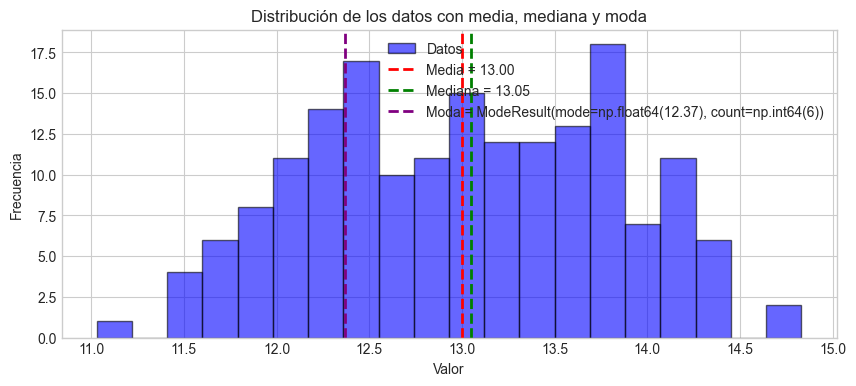

In [46]:
plt.figure(figsize=(10, 4))
plt.hist(x, bins=20, alpha=0.6, color='blue', edgecolor='black', label='Datos')
plt.axvline(x.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Media = {x.mean():.2f}')
plt.axvline(x.median(), color='green', linestyle='dashed', linewidth=2, label=f'Mediana = {x.median():.2f}')
plt.axvline(stats.mode(x)[0], color='purple', linestyle='dashed', linewidth=2, label=f'Moda = {stats.mode(x)}')
plt.title('Distribución de los datos con media, mediana y moda')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

### Cuantiles o percentiles

- **Cuartiles:** Dividen los datos en 4 partes iguales.
- **Deciles:** Dividen los datos en 10 partes iguales.
- **Percentiles:** Dividen los datos en 100 partes iguales.

#### Cuartiles

Dada una muestra $x_1,x_2,...,x_n$, podemos ordenar los datos de menor a mayor y dividirlos en cuatro partes con la misma cantidad de datos. Los cortes de estas divisiones son lo que llamamos cuartiles. Para dividir un conjunto de datos en cuatro partes, necesitamos tres cuartiles, identificados como $Q_1$, $Q_2$ y $Q_3$.

Junto con el mínimo y el máximo, estos 5 valores sirven para resumir la distribución de una variable, con menos detalle que un histograma pero con más información que usando sólo la media y la varianza.

In [47]:
x.quantile(0.25) # Primer cuartíl

np.float64(12.362499999999999)

In [48]:
x.quantile(0.1) # Primer decíl

np.float64(11.933)

In [49]:
np.quantile(x,0.25)

np.float64(12.362499999999999)

In [50]:
np.quantile(x,[0.25,0.5,0.75]) # Primero, segundo y tercer cuartíl

array([12.3625, 13.05  , 13.6775])

In [51]:
x.quantile([0.25,0.5,0.75])

0.250   12.362
0.500   13.050
0.750   13.678
Name: alcohol, dtype: float64

In [52]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893,0.938
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907,0.775
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000,0.000
25%,12.362,1.603,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500,0.000
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500,1.000
75%,13.678,3.083,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000,2.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,"1,680.000",2.000


El segundo cuartil es igual a la Mediana, un estadístico que también se puede considerar una medida de tendencia central. 

In [53]:
x.quantile(0.5), x.median()

(np.float64(13.05), np.float64(13.05))

In [54]:
np.percentile(x,25) # Primer cuartíl

np.float64(12.362499999999999)

In [55]:
q1 = np.percentile(x, 25)
q2 = np.percentile(x, 50)  # Mediana
q3 = np.percentile(x, 75)
percentil_90 = np.percentile(x, 90)
decil_3 = np.percentile(x, 30)
print('Q1 (25%):', q1)
print('Q2 (Mediana, 50%):', q2)
print('Q3 (75%):', q3)
print('Percentil 90:', percentil_90)
print('Decil 3 (30%):', decil_3)

Q1 (25%): 12.362499999999999
Q2 (Mediana, 50%): 13.05
Q3 (75%): 13.6775
Percentil 90: 14.1
Decil 3 (30%): 12.421


##### Rango intercuartílico

La diferencia entre el $Q_3$ y $Q_1$ es lo que llamamos Rango intercuartílico y lo representamos con $IQR$ por Inter-quartile range. Es una medida de dispersión de los datos, ya que representa el ancho del 50% central de los datos. Mientras más dispersos estén los datos, mayor será esta distancia.

$$IQR=Q_3−Q_1$$

In [56]:
stats.iqr(x,rng=(0,100))

np.float64(3.8000000000000007)

In [57]:
#@title Rango intercuartílico
stats.iqr(x)

np.float64(1.3150000000000013)

In [58]:
q1,q3=np.quantile(x,(0.25,0.75))
q1,q3

(np.float64(12.362499999999999), np.float64(13.6775))

In [59]:
q3-q1

np.float64(1.3150000000000013)

In [60]:
q1,q3=x.quantile([0.25,0.75])

In [61]:
q1,q3

(12.362499999999999, 13.6775)

##### Representación gráfica

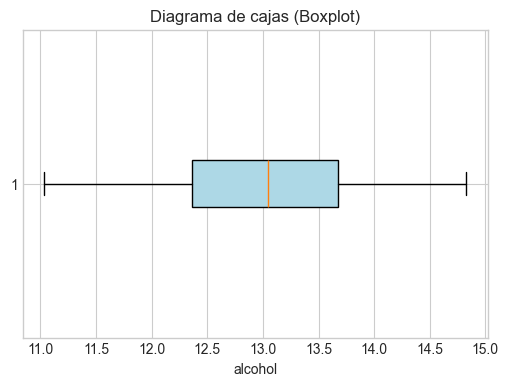

In [62]:
plt.figure(figsize=(6, 4))
plt.boxplot(x, vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Diagrama de cajas (Boxplot)')
plt.xlabel('alcohol')
plt.show()

1. En este caso la característica está representada en el eje x.
2. La línea vertical del medio de la caja, en "amarillo", es la mediana
3. La línea vertical izquierda de la caja es el 1er cuartil, y la línea vertical de la derecha es el 3er cuartil.
5. El ancho de la caja es el Rango intercuartílico $IQR$. Por lo tanto, mientras mayor sea la dispersión, más grande será la caja.
6. Los extremos de las líneas verticales, son llamados Bigotes son el mínimo y el máximo. Cuando hay valores atípicos, son los valores más bajos y altos que no sean valores atípicos.
7. Los valores atípicos se definen en este contexto como valores más altos que $Q_3+(1.5∗IQR)$
 o más bajos que $Q_1−(1.5∗IQR)$. Estos valores se representan con puntos.

# Medidas de disperción

### Varianza y desviación estandar

La **varianza** y la **desviación estándar** son medidas de dispersión que indican cuánto se alejan los datos respecto a la media.

$$ \sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2 $$

Para una muestra, la fórmula es:

$$ s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2 $$

Donde:
- $x_i$ son los valores de los datos.
- $\bar{x}$ es la media.
- $n$ es el número de datos.

In [63]:
x = np.array([10, 12, 15, 18, 20])
varianza_poblacional = x.var(ddof=0)
varianza_muestral = x.var(ddof=1)
desv_std_poblacional = x.std(ddof=0)
desv_std_muestral = x.std(ddof=1)
print('Varianza poblacional:', varianza_poblacional)
print('Varianza muestral:', varianza_muestral)
print('Desviación estándar poblacional:', desv_std_poblacional)
print('Desviación estándar muestral:', desv_std_muestral)

Varianza poblacional: 13.6
Varianza muestral: 17.0
Desviación estándar poblacional: 3.687817782917155
Desviación estándar muestral: 4.123105625617661


- `x.std(ddof=0)`: Calcula la desviación estándar considerando que los datos corresponden a toda la población. El divisor es $n$.
- `x.std(ddof=1)`: Calcula la desviación estándar muestral, es decir, cuando los datos son una muestra de una población más grande. El divisor es $n-1$ (corrección de Bessel).

La corrección de Bessel (`ddof=1`) ajusta el sesgo en la estimación de la varianza y desviación estándar cuando se trabaja con muestras.

In [64]:
df.head(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.230,1.710,2.430,15.600,127.000,2.800,3.060,0.280,2.290,5.640,1.040,3.920,"1,065.000",0
1,13.200,1.780,2.140,11.200,100.000,2.650,2.760,0.260,1.280,4.380,1.050,3.400,"1,050.000",0


In [65]:
x.var() # Varianza muestral

np.float64(13.6)

In [66]:
x.std() # Desviación estandar muestral

np.float64(3.687817782917155)

In [67]:
df.std()

alcohol                          0.812
malic_acid                       1.117
ash                              0.274
alcalinity_of_ash                3.340
magnesium                       14.282
total_phenols                    0.626
flavanoids                       0.999
nonflavanoid_phenols             0.124
proanthocyanins                  0.572
color_intensity                  2.318
hue                              0.229
od280/od315_of_diluted_wines     0.710
proline                        314.907
target                           0.775
dtype: float64

In [68]:
np.var(x) # Varianza del conjunto completo

np.float64(13.6)

In [69]:
np.std(x) # Std del conjunto completo

np.float64(3.687817782917155)

In [70]:
x.var(ddof=0) # Varianza del conjunto completo

np.float64(13.6)

In [71]:
x.std(ddof=0) # Std del conjunto completo

np.float64(3.687817782917155)

### Recorrido max-min

Es una medida de dispersión que se calcula como la diferencia entre el valor máximo y el valor mínimo de un conjunto de datos.

$$ R = x_{\text{max}} - x_{\text{min}} $$

Donde:
- $x_{\text{max}}$ es el valor máximo del conjunto de datos.
- $x_{\text{min}}$ es el valor mínimo del conjunto de datos.


In [72]:
# Rango
x.max()-x.min() # Desde Pandas

np.int64(10)

In [73]:
np.max(x)-np.min(x) # Desde Numpy

np.int64(10)

In [74]:
max(x)-min(x) # 

np.int64(10)

In [75]:
np.ptp(x)

np.int64(10)

In [76]:
df.max()-df.min()

alcohol                            3.800
malic_acid                         5.060
ash                                1.870
alcalinity_of_ash                 19.400
magnesium                         92.000
total_phenols                      2.900
flavanoids                         4.740
nonflavanoid_phenols               0.530
proanthocyanins                    3.170
color_intensity                   11.720
hue                                1.230
od280/od315_of_diluted_wines       2.730
proline                        1,402.000
target                             2.000
dtype: float64

In [77]:
np.max(df,axis=0)-np.min(df,axis=0)

alcohol                            3.800
malic_acid                         5.060
ash                                1.870
alcalinity_of_ash                 19.400
magnesium                         92.000
total_phenols                      2.900
flavanoids                         4.740
nonflavanoid_phenols               0.530
proanthocyanins                    3.170
color_intensity                   11.720
hue                                1.230
od280/od315_of_diluted_wines       2.730
proline                        1,402.000
target                             2.000
dtype: float64

El recorrido max-min:

- Es muy fácil y rápido de calcular.
- Permite obtener una idea rápida de la dispersión total de los datos.
- Es útil para comparar la variabilidad entre diferentes conjuntos de datos.
- No requiere cálculos complejos ni fórmulas avanzadas.

### Coeficiente de variación de Pearson

Es una medida relativa de dispersión que indica el grado de variabilidad de los datos respecto a su media. Se expresa como un porcentaje y permite comparar la dispersión entre diferentes conjuntos de datos, incluso si tienen unidades o medias distintas.

$$ CV = \frac{\sigma}{\bar{x}} \times 100 $$

Donde:
- $\sigma$ es la desviación estándar.
- $\bar{x}$ es la media.


- Un CV bajo indica que los datos están poco dispersos respecto a la media.
- Un CV alto indica mayor dispersión relativa.

Supongamos que tenemos dos conjuntos de datos con:

- A: media = 50, desviación estándar = 5 → CV = (5/50)*100 = 10%
- B: media = 100, desviación estándar = 20 → CV = (20/100)*100 = 20%

Podemos concluir que el conjunto B es relativamente más disperso que el conjunto A.

In [78]:
# Coeficiente de variación de Pearson
stats.variation(x)

np.float64(0.24585451886114368)

In [79]:
stats.variation(df)

array([0.06226957, 0.47681402, 0.11560124, 0.17082223, 0.14279209,
       0.27192157, 0.4908411 , 0.34296507, 0.35875872, 0.45704302,
       0.23805811, 0.27108673, 0.42043713, 0.82376147])

In [80]:
df.std(ddof=0)

alcohol                          0.810
malic_acid                       1.114
ash                              0.274
alcalinity_of_ash                3.330
magnesium                       14.242
total_phenols                    0.624
flavanoids                       0.996
nonflavanoid_phenols             0.124
proanthocyanins                  0.571
color_intensity                  2.312
hue                              0.228
od280/od315_of_diluted_wines     0.708
proline                        314.022
target                           0.773
dtype: float64

In [81]:
x.std(ddof=0)/np.abs(x.mean())

np.float64(0.24585451886114368)

# Medidas de forma

Las **medidas de forma** describen la forma de la distribución de los datos, permitiendo identificar si los datos están sesgados (asimetría) o si presentan colas y picos más o menos pronunciados que una distribución normal (curtosis).


#### Asimetría (skewness)

Formalmente, decimos que una distribución de frecuencias es simétrica si la media aritmética $\bar{X}$ es igual a la mediana $X_M$. Esto significa que en cualquier otro caso, la distribución es asimétrica.

**Tercer momento central**

El $k$-ésimo momento central de una variable aleatoria $X$ es:

$$ \mu_k = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^k $$

Para $k=3$ (tercer momento central):

$$ \mu_3 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^3 $$

La asimetría se define como:

$$ \text{Asimetría} = \gamma_1 = \frac{\mu_3}{\sigma^3} $$

Donde:
- $\mu_3$ es el tercer momento central.
- $\sigma$ es la desviación estándar.

Esta fórmula permite cuantificar la asimetría de una distribución en función de sus momentos centrales.
> Si $\text{Asimetría}=0$, la distribución es simétrica.

> Si $\text{Asimetría}>0$, la cola derecha es más larga (asimetría a la derecha).

> Si $\text{Asimetría}<0$, la cola izquierda es más larga (asimetría a la izquierda).

In [82]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

#Datos Simétricos
datos_simetricos = np.random.normal(loc=0, scale=1, size=1000)
media_sim = np.mean(datos_simetricos)
mediana_sim = np.median(datos_simetricos)

#datos asimétricos positivos (distribución exponencial)
datos_asim_pos = np.random.exponential(scale=1, size=1000)
media_pos = np.mean(datos_asim_pos)
mediana_pos = np.median(datos_asim_pos)

# Datos asimétricos negativos (simulación: invertir exponencial)
datos_asim_neg = -np.random.exponential(scale=1, size=1000)
media_neg = np.mean(datos_asim_neg)
mediana_neg = np.median(datos_asim_neg)

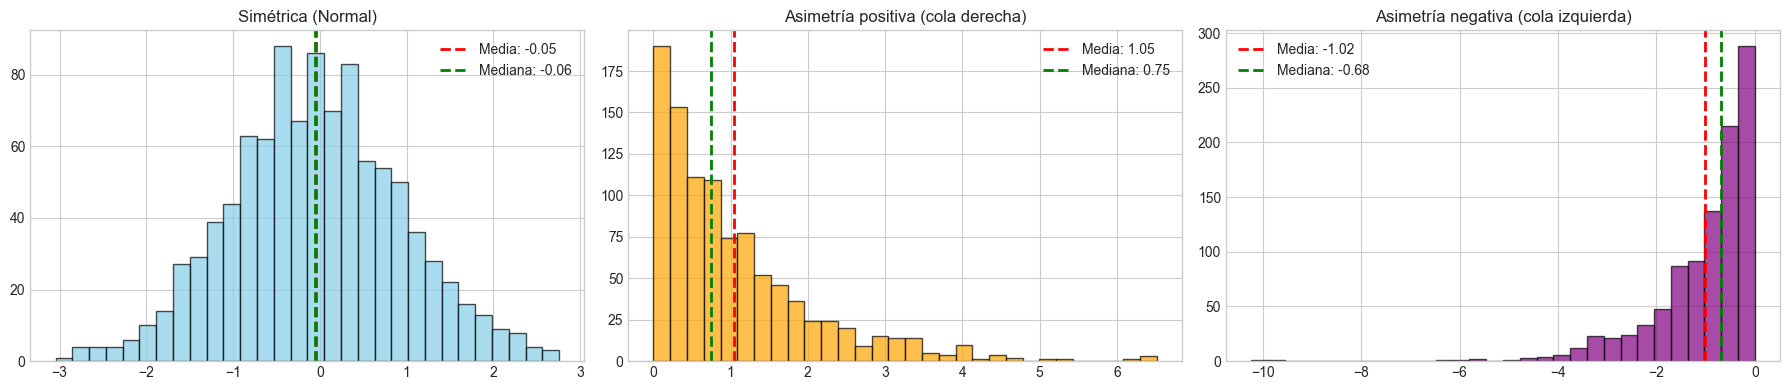

In [83]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
# Gráfica simétrica
axs[0].hist(datos_simetricos, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axs[0].axvline(media_sim, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_sim:.2f}')
axs[0].axvline(mediana_sim, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_sim:.2f}')
axs[0].set_title('Simétrica (Normal)')
axs[0].legend()

# Gráfica asimetría positiva
axs[1].hist(datos_asim_pos, bins=30, color='orange', edgecolor='black', alpha=0.7)
axs[1].axvline(media_pos, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_pos:.2f}')
axs[1].axvline(mediana_pos, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_pos:.2f}')
axs[1].set_title('Asimetría positiva (cola derecha)')
axs[1].legend()

# Gráfica asimetría negativa
axs[2].hist(datos_asim_neg, bins=30, color='purple', edgecolor='black', alpha=0.7)
axs[2].axvline(media_neg, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_neg:.2f}')
axs[2].axvline(mediana_neg, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_neg:.2f}')
axs[2].set_title('Asimetría negativa (cola izquierda)')
axs[2].legend()

plt.tight_layout()
plt.show()

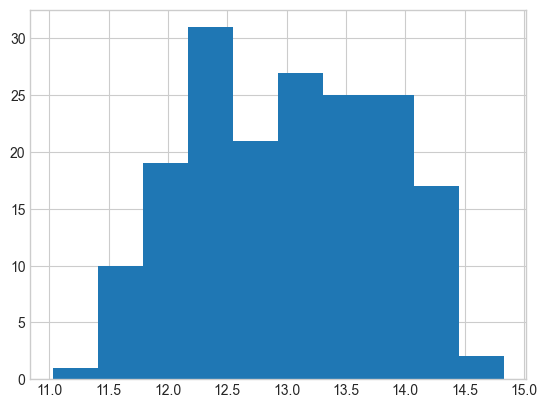

In [84]:
#Graficamos la distribución de nuestros datos
plt.hist(df['alcohol']);

In [85]:
# (Simetría/Sesgo) de la caracterísitca 'alcohol'
df['alcohol'].skew()

np.float64(-0.051482331077134784)

In [86]:
df.skew()

alcohol                        -0.051
malic_acid                      1.040
ash                            -0.177
alcalinity_of_ash               0.213
magnesium                       1.098
total_phenols                   0.087
flavanoids                      0.025
nonflavanoid_phenols            0.450
proanthocyanins                 0.517
color_intensity                 0.869
hue                             0.021
od280/od315_of_diluted_wines   -0.307
proline                         0.768
target                          0.107
dtype: float64

<Axes: >

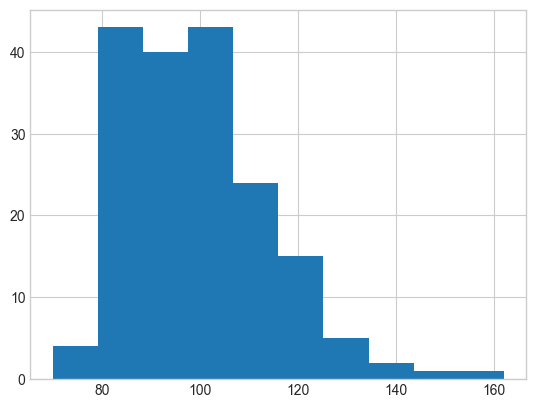

In [87]:
df['magnesium'].hist()

<Axes: >

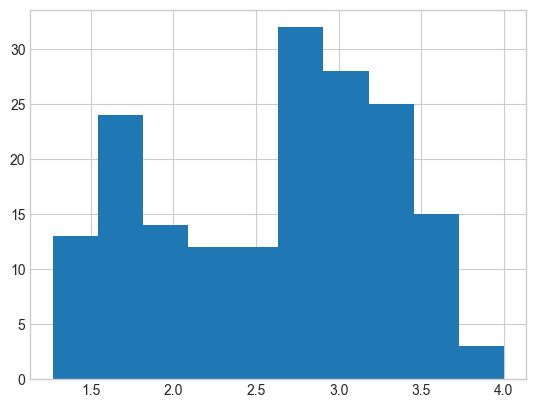

In [88]:
df['od280/od315_of_diluted_wines'].hist()

### Curtósis

Otra medida de forma es la **curtosis**, relacionada con el peso de las colas y la concentración central. Hay dos convenciones frecuentes:

- **Curtosis de Pearson:** una normal tiene valor 3.
- **Curtosis excedente:** se resta 3, por lo que una normal tiene valor 0.

`pandas.Series.kurt()` y `scipy.stats.kurtosis()` usan por defecto la curtosis excedente (`fisher=True`). Por eso no se debe comparar directamente su resultado con la afirmación "una normal vale 3" sin ajustar la convención.

La curtosis orienta sobre colas y valores extremos, pero no es una prueba de normalidad por sí sola.

In [89]:
# Distribución mesocúrtica (normal)
np.random.seed(0)
mesocurtica = np.random.normal(loc=0, scale=1, size=1000)
media_meso = np.mean(mesocurtica)
mediana_meso = np.median(mesocurtica)

# Distribución leptocúrtica (Laplace: picos altos y colas largas)
leptocurtica = np.random.laplace(loc=0, scale=0.5, size=1000)
media_lepto = np.mean(leptocurtica)
mediana_lepto = np.median(leptocurtica)

# Distribución platicúrtica (Uniforme: picos bajos y colas cortas)
platicurtica = np.random.uniform(low=-2, high=2, size=1000)
media_plati = np.mean(platicurtica)
mediana_plati = np.median(platicurtica)


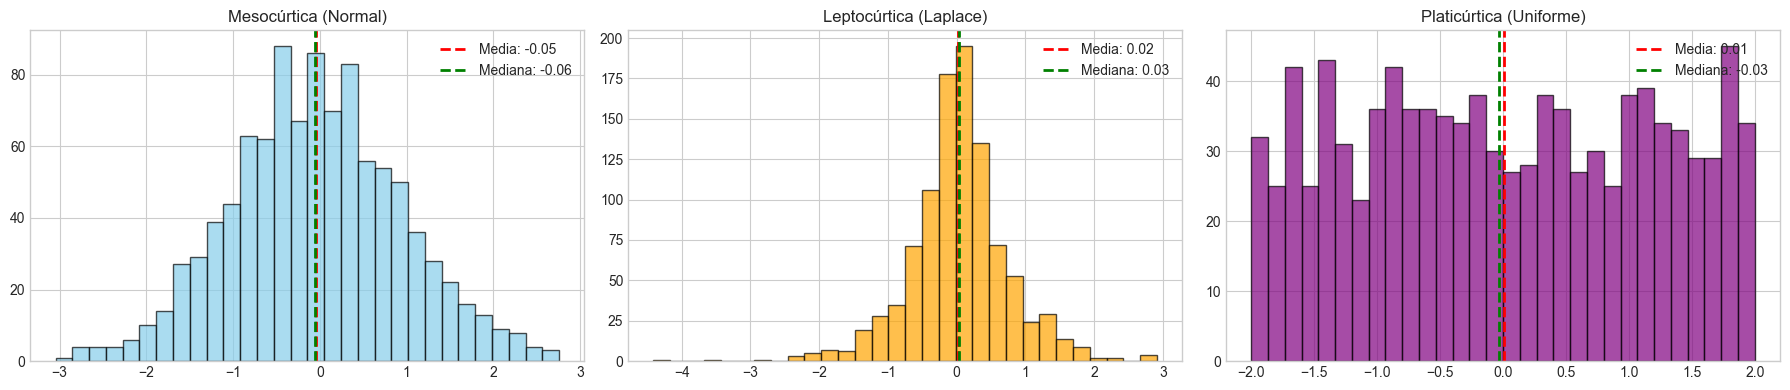

In [90]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))

# Mesocúrtica
axs[0].hist(mesocurtica, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axs[0].axvline(media_meso, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_meso:.2f}')
axs[0].axvline(mediana_meso, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_meso:.2f}')
axs[0].set_title('Mesocúrtica (Normal)')
axs[0].legend()

# Leptocúrtica
axs[1].hist(leptocurtica, bins=30, color='orange', edgecolor='black', alpha=0.7)
axs[1].axvline(media_lepto, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_lepto:.2f}')
axs[1].axvline(mediana_lepto, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_lepto:.2f}')
axs[1].set_title('Leptocúrtica (Laplace)')
axs[1].legend()

# Platicúrtica
axs[2].hist(platicurtica, bins=30, color='purple', edgecolor='black', alpha=0.7)
axs[2].axvline(media_plati, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_plati:.2f}')
axs[2].axvline(mediana_plati, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_plati:.2f}')
axs[2].set_title('Platicúrtica (Uniforme)')
axs[2].legend()

plt.tight_layout()
plt.show()

In [91]:
curtosis_excedente = df['alcohol'].kurt()
curtosis_pearson = curtosis_excedente + 3
print(f'Curtosis excedente: {curtosis_excedente:.3f}')
print(f'Curtosis de Pearson: {curtosis_pearson:.3f}')

Curtosis excedente: -0.852
Curtosis de Pearson: 2.148


In [92]:
df.kurt()

alcohol                        -0.852
malic_acid                      0.299
ash                             1.144
alcalinity_of_ash               0.488
magnesium                       2.105
total_phenols                  -0.836
flavanoids                     -0.880
nonflavanoid_phenols           -0.637
proanthocyanins                 0.555
color_intensity                 0.382
hue                            -0.344
od280/od315_of_diluted_wines   -1.086
proline                        -0.248
target                         -1.323
dtype: float64

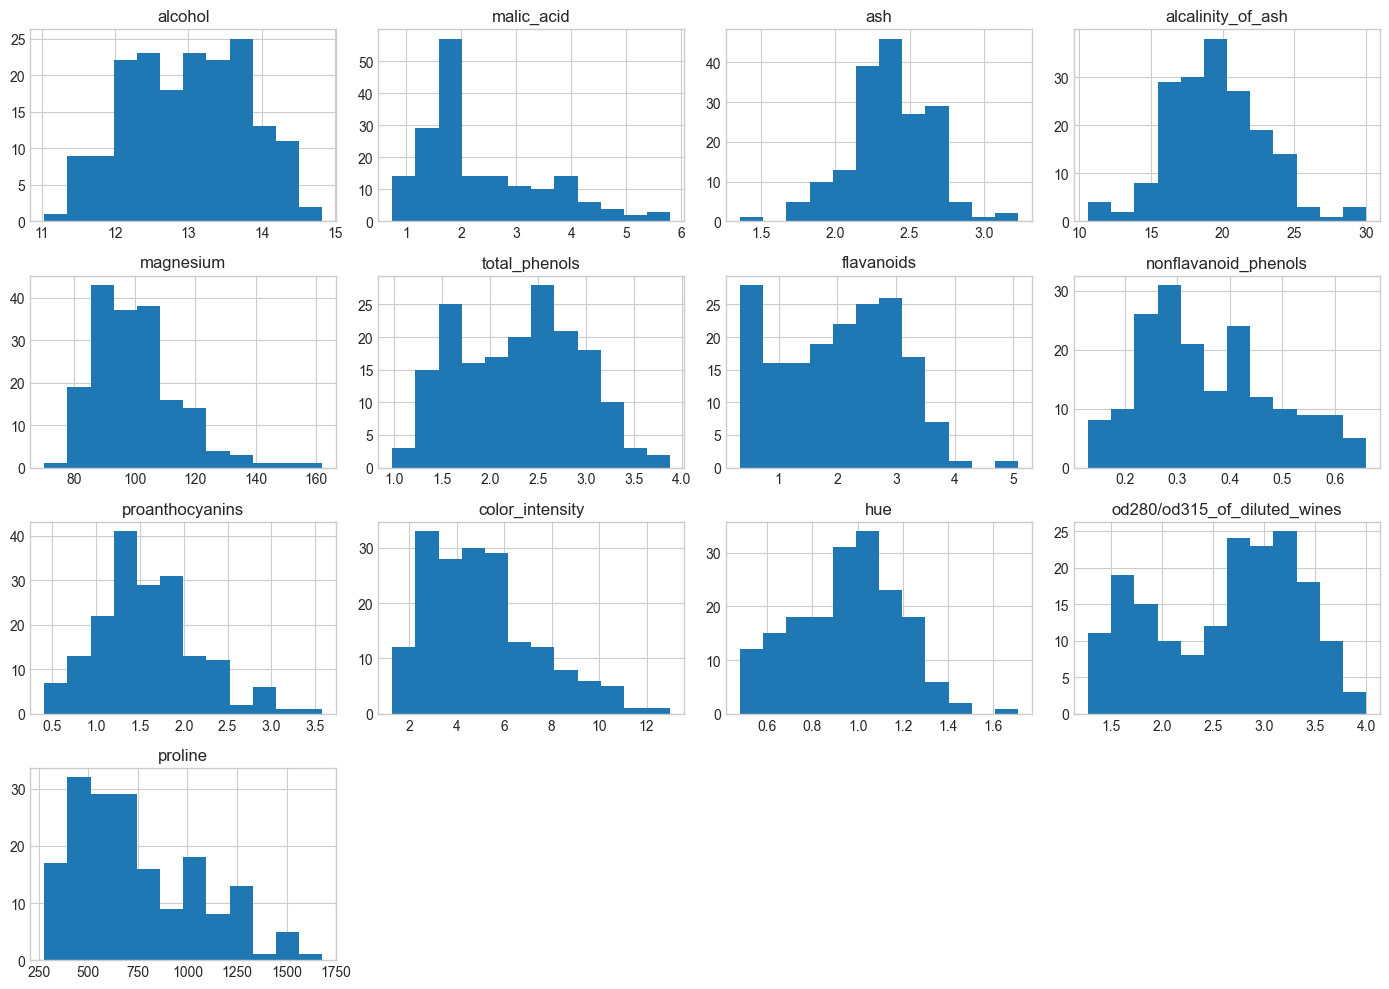

In [93]:
df.drop(columns='target').hist(figsize=(14, 10), bins=12)
plt.tight_layout()
plt.show()

Los datos reales son más complejos que la teoría, incluso estos que son batante sencillos. Se recomienda siempre acompañar el análisis de la asimetría con algún gráfico como un histograma, un diagrama de cajas, un polígono de frecuencias, etc.

Un diagnóstico útil combina evidencia numérica y gráfica. No concluyas que una variable es normal solo porque su media y mediana son parecidas, ni declares un valor como atípico únicamente por verlo alejado.

### Actividad de clase

1. Elige dos variables del dataset con formas diferentes. Compara sus histogramas y diagramas de caja.
2. Calcula para cada una media, mediana, desviación estándar, `Q1`, `Q3`, `IQR`, asimetría y curtosis excedente.
3. Decide cuál medida de centro reportarías y justifica la decisión con la forma observada.
4. Identifica una variable con posible asimetría. ¿Qué transformación probarías: logaritmo, raíz cuadrada, Box-Cox o ninguna? Explica las restricciones de tu elección.
5. Observa el gráfico Q-Q. ¿Qué patrón esperarías si las colas observadas fueran más pesadas que las de una normal?

### Reto

Crea una función `diagnostico_distribucion(serie)` que devuelva una fila con `media`, `mediana`, `desviacion`, `q1`, `q3`, `iqr`, `asimetria` y `curtosis_excedente`. Aplícala a todas las características numéricas y ordena el resultado por asimetría absoluta.

Recuerda: 
- Una estadística resume, una gráfica ayuda a interpretar, el contexto decide.